In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from IPython.display import display
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from torch.utils.data import Dataset, DataLoader

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

FEATURE_COLS = [
    "acousticness",
    "danceability",
    "duration_ms",
    "energy",
    "instrumentalness",
    "key",
    "liveness",
    "loudness",
    "mode",
    "speechiness",
    "tempo",
    "time_signature",
    "valence",
    "popularity"
]

CONTINUOUS_FEATURE_COLS = [
    "acousticness",
    "danceability",
    "duration_ms",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence",
    "popularity"
]

CATEGORICAL_FEATURE_COLS = ["key", "mode", "time_signature"]
CATEGORICAL_INPUT_COLS = ["key_cat", "mode_cat", "time_signature_cat"]

ID_COL = "id"
NAME_COL = "name"
LABEL_COL = "category_name"

LABEL_TO_IDX = {"active": 0, "relax": 1}
IDX_TO_LABEL = {0: "active", 1: "relax"}
CLASS_NAMES = [IDX_TO_LABEL[0], IDX_TO_LABEL[1]]

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


,split,rows,unique_ids,active_count,relax_count
0,original_full,12196,12196,6288,5908
1,train,10365,10365,5344,5021
2,validation,1831,1831,944,887
3,new_data_test,3051,3051,1573,1478



Features used by the baseline model:
['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'log_duration_ms', 'log_tempo', 'energy_valence', 'dance_energy', 'acoustic_instr', 'loudness_energy', 'speech_energy', 'valence_minus_acoustic', 'energy_minus_acoustic', 'dance_valence', 'key', 'mode', 'time_signature']

Features used by the neural component of the primary model:
['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'log_duration_ms', 'log_tempo', 'energy_valence', 'dance_energy', 'acoustic_instr', 'loudness_energy', 'speech_energy', 'valence_minus_acoustic', 'energy_minus_acoustic', 'dance_valence', 'sqrt_instrumentalness', 'sqrt_acousticness', 'sqrt_speechiness', 'sqrt_liveness', 'tempo_energy_ratio', 'calm_index', 'intensity_index', 'key_sin', 'key_cos', 'mode_signed', 'time_signature

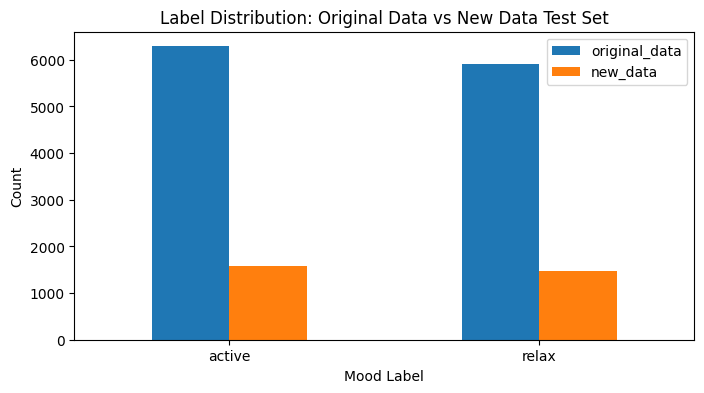

Original data sample:


,name,category_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,Pop Smoke,active,0.00173,0.838,368025,0.9880,0.76600,11.0,0.0501,-7.053,0.0,0.0959,126.020,4.0,0.367,21
1,Rock-a-bye Baby,relax,0.98400,0.592,110216,0.0827,0.87900,5.0,0.1180,-30.577,1.0,0.0389,64.297,4.0,0.448,68
2,Papa à demi,relax,0.88400,0.439,182000,0.1900,0.00339,11.0,0.1590,-13.343,0.0,0.0424,147.768,4.0,0.237,0
3,Skyline,active,0.01790,0.733,182895,0.6530,0.02180,11.0,0.1840,-6.094,1.0,0.0391,119.996,5.0,0.752,73
4,The Business,active,0.41400,0.798,164000,0.6200,0.01920,8.0,0.1120,-7.079,0.0,0.2320,120.031,4.0,0.235,82


New data test sample:


,name,category_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,Be My Mistake,active,0.8350,0.572,256687,0.155,0.000137,6.0,0.0906,-14.405,1.0,0.0344,109.923,3.0,0.09490,74
1,Give You What You Want,active,0.2220,0.691,159330,0.656,0.001110,10.0,0.1530,-5.673,0.0,0.0679,89.467,4.0,0.39300,74
2,Standing In The Rain,relax,0.3240,0.132,162992,0.952,0.954000,11.0,0.8430,-30.951,0.0,0.0589,66.484,3.0,0.00001,56
3,Don't It Drive You Crazy,active,0.1270,0.550,379426,0.739,0.000156,2.0,0.5100,-9.742,0.0,0.0469,83.456,4.0,0.91800,35
4,You,relax,0.0592,0.691,233386,0.695,0.000000,0.0,0.0647,-5.600,1.0,0.0367,106.064,4.0,0.51400,75


In [3]:
def add_engineered_features(df):
    df = df.copy()

    df["log_duration_ms"] = np.log1p(df["duration_ms"].clip(lower=0))
    df["log_tempo"] = np.log1p(df["tempo"].clip(lower=0))
    df["energy_valence"] = df["energy"] * df["valence"]
    df["dance_energy"] = df["danceability"] * df["energy"]
    df["acoustic_instr"] = df["acousticness"] * df["instrumentalness"]
    df["loudness_energy"] = df["loudness"] * df["energy"]
    df["speech_energy"] = df["speechiness"] * df["energy"]
    df["valence_minus_acoustic"] = df["valence"] - df["acousticness"]
    df["energy_minus_acoustic"] = df["energy"] - df["acousticness"]
    df["dance_valence"] = df["danceability"] * df["valence"]

    df["sqrt_instrumentalness"] = np.sqrt(df["instrumentalness"].clip(lower=0))
    df["sqrt_acousticness"] = np.sqrt(df["acousticness"].clip(lower=0))
    df["sqrt_speechiness"] = np.sqrt(df["speechiness"].clip(lower=0))
    df["sqrt_liveness"] = np.sqrt(df["liveness"].clip(lower=0))
    df["tempo_energy_ratio"] = df["tempo"] / (df["energy"] + 0.15)
    df["calm_index"] = df["acousticness"] + df["instrumentalness"] + 0.5 * df["valence"] - 0.5 * df["energy"]
    df["intensity_index"] = df["energy"] + df["danceability"] + 0.25 * df["loudness"] - df["acousticness"]
    df["key_sin"] = np.sin(2 * np.pi * df["key"] / 12.0)
    df["key_cos"] = np.cos(2 * np.pi * df["key"] / 12.0)
    df["mode_signed"] = df["mode"].replace({0: -1, 1: 1})
    df["time_signature_centered"] = df["time_signature"] - df["time_signature"].median()

    df["pop_x_energy"] = df["popularity"] * df["energy"]
    df["pop_x_dance"] = df["popularity"] * df["danceability"]
    df["duration_x_acoustic"] = df["log_duration_ms"] * df["acousticness"]
    df["loudness_x_valence"] = df["loudness"] * df["valence"]
    df["acoustic_minus_speech"] = df["acousticness"] - df["speechiness"]

    for original_col, cat_col in zip(CATEGORICAL_FEATURE_COLS, CATEGORICAL_INPUT_COLS):
        df[cat_col] = df[original_col].astype(int)

    return df

BASE_ENGINEERED_FEATURE_COLS = [
    "log_duration_ms",
    "log_tempo",
    "energy_valence",
    "dance_energy",
    "acoustic_instr",
    "loudness_energy",
    "speech_energy",
    "valence_minus_acoustic",
    "energy_minus_acoustic",
    "dance_valence",
]

PRIMARY_EXTRA_FEATURE_COLS = [
    "sqrt_instrumentalness",
    "sqrt_acousticness",
    "sqrt_speechiness",
    "sqrt_liveness",
    "tempo_energy_ratio",
    "calm_index",
    "intensity_index",
    "key_sin",
    "key_cos",
    "mode_signed",
    "time_signature_centered",
]

STACKING_EXTRA_FEATURE_COLS = [
    "pop_x_energy",
    "pop_x_dance",
    "duration_x_acoustic",
    "loudness_x_valence",
    "acoustic_minus_speech",
]

PRIMARY_CONTINUOUS_COLS = CONTINUOUS_FEATURE_COLS + BASE_ENGINEERED_FEATURE_COLS + PRIMARY_EXTRA_FEATURE_COLS + STACKING_EXTRA_FEATURE_COLS
BASELINE_FEATURE_COLS = CONTINUOUS_FEATURE_COLS + BASE_ENGINEERED_FEATURE_COLS + CATEGORICAL_FEATURE_COLS
TREE_FEATURE_COLS = PRIMARY_CONTINUOUS_COLS + CATEGORICAL_FEATURE_COLS
NN_STANDARDIZED_FEATURE_COLS = CONTINUOUS_FEATURE_COLS + BASE_ENGINEERED_FEATURE_COLS + PRIMARY_EXTRA_FEATURE_COLS + STACKING_EXTRA_FEATURE_COLS + CATEGORICAL_FEATURE_COLS
REPORT_FEATURE_COLS = TREE_FEATURE_COLS

original_data_df = pd.read_csv("spotify_original_data.csv")
new_data_df = pd.read_csv("spotify_new_data.csv")

original_data_df = original_data_df[[ID_COL, NAME_COL] + FEATURE_COLS + [LABEL_COL]].copy()
new_data_df = new_data_df[[ID_COL, NAME_COL] + FEATURE_COLS + [LABEL_COL]].copy()

original_data_df = original_data_df[original_data_df[LABEL_COL].isin(CLASS_NAMES)].drop_duplicates(subset=[ID_COL]).copy()
new_data_df = new_data_df[new_data_df[LABEL_COL].isin(CLASS_NAMES)].drop_duplicates(subset=[ID_COL]).copy()

original_data_df = add_engineered_features(original_data_df)
new_data_df = add_engineered_features(new_data_df)

original_data_df["label"] = original_data_df[LABEL_COL].map(LABEL_TO_IDX)
new_data_df["label"] = new_data_df[LABEL_COL].map(LABEL_TO_IDX)

def stratified_split(df, label_col="label", train_frac=0.85, seed=42):
    train_parts, val_parts = [], []

    for label_value in sorted(df[label_col].unique()):
        group = df[df[label_col] == label_value].sample(frac=1.0, random_state=seed).reset_index(drop=True)
        n_train = int(len(group) * train_frac)
        train_parts.append(group.iloc[:n_train])
        val_parts.append(group.iloc[n_train:])

    train_df = pd.concat(train_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    val_df = pd.concat(val_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return train_df, val_df

train_df, val_df = stratified_split(original_data_df)
train_tree_df = train_df.copy()
val_tree_df = val_df.copy()
new_data_tree_df = new_data_df.copy()

def standardize(df, feature_cols, means, stds):
    df = df.copy()
    scaled = ((df[feature_cols].astype(float) - means) / stds).astype(float)
    for col in feature_cols:
        df[col] = scaled[col]
    return df

train_means = train_df[NN_STANDARDIZED_FEATURE_COLS].astype(float).mean()
train_stds = train_df[NN_STANDARDIZED_FEATURE_COLS].astype(float).std().replace(0, 1)

train_df = standardize(train_df, NN_STANDARDIZED_FEATURE_COLS, train_means, train_stds)
val_df = standardize(val_df, NN_STANDARDIZED_FEATURE_COLS, train_means, train_stds)
new_data_df = standardize(new_data_df, NN_STANDARDIZED_FEATURE_COLS, train_means, train_stds)

def split_summary(df, split_name):
    counts = df[LABEL_COL].value_counts().reindex(CLASS_NAMES, fill_value=0)
    return {
        "split": split_name,
        "rows": len(df),
        "unique_ids": df[ID_COL].nunique(),
        "active_count": int(counts["active"]),
        "relax_count": int(counts["relax"]),
    }

summary_df = pd.DataFrame([
    split_summary(original_data_df, "original_full"),
    split_summary(train_tree_df, "train"),
    split_summary(val_tree_df, "validation"),
    split_summary(new_data_tree_df, "new_data_test"),
])

display(summary_df)

print("\nFeatures used by the baseline model:")
print(BASELINE_FEATURE_COLS)
print("\nFeatures used by the neural component of the primary model:")
print(PRIMARY_CONTINUOUS_COLS, "+", CATEGORICAL_INPUT_COLS)
print("\nFeatures used by the boosting component of the primary model:")
print(TREE_FEATURE_COLS)

plt.figure(figsize=(8, 4))
summary_plot_df = pd.DataFrame({
    "original_data": original_data_df[LABEL_COL].value_counts().reindex(CLASS_NAMES, fill_value=0),
    "new_data": new_data_tree_df[LABEL_COL].value_counts().reindex(CLASS_NAMES, fill_value=0),
})
summary_plot_df.plot(kind="bar", ax=plt.gca())
plt.title("Label Distribution: Original Data vs New Data Test Set")
plt.xlabel("Mood Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

print("Original data sample:")
display(original_data_df[[NAME_COL, LABEL_COL] + FEATURE_COLS].head(5))

print("New data test sample:")
display(new_data_tree_df[[NAME_COL, LABEL_COL] + FEATURE_COLS].head(5))


In [4]:
class SpotifyMoodDataset(Dataset):
    def __init__(self, df):
        self.baseline_features = torch.tensor(df[BASELINE_FEATURE_COLS].values, dtype=torch.float32)
        self.primary_continuous = torch.tensor(df[PRIMARY_CONTINUOUS_COLS].values, dtype=torch.float32)
        self.primary_categorical = torch.tensor(df[CATEGORICAL_INPUT_COLS].values, dtype=torch.long)
        self.labels = torch.tensor(df["label"].values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "baseline_features": self.baseline_features[idx],
            "primary_continuous": self.primary_continuous[idx],
            "primary_categorical": self.primary_categorical[idx],
            "labels": self.labels[idx],
        }

train_dataset = SpotifyMoodDataset(train_df)
val_dataset = SpotifyMoodDataset(val_df)
new_data_dataset = SpotifyMoodDataset(new_data_df)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
new_data_loader = DataLoader(new_data_dataset, batch_size=256, shuffle=False)

def move_batch_to_device(batch, device="cpu"):
    return {key: value.to(device) for key, value in batch.items()}

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def class_weight_tensor(labels, device="cpu"):
    class_counts = labels.value_counts().sort_index().values
    weights = len(labels) / (len(class_counts) * class_counts)
    return torch.tensor(weights, dtype=torch.float32, device=device)

def predict_probabilities_torch(model, data_loader, device="cpu"):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for batch in data_loader:
            batch = move_batch_to_device(batch, device)
            logits = model(batch)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            labels = batch["labels"].cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels)

    return np.concatenate(all_probs), np.concatenate(all_labels)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0,
    )

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_relax": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
        "brier_score": brier_score_loss(y_true, y_prob),
        "precision_active": precision[0],
        "recall_active": recall[0],
        "f1_active": f1[0],
        "precision_relax": precision[1],
        "recall_relax": recall[1],
        "threshold": threshold,
    }
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return metrics, cm, y_pred

def bootstrap_interval(y_true, y_prob, metric_name, threshold=0.5, num_bootstrap=250, seed=42):
    rng = np.random.default_rng(seed)
    y_pred = (y_prob >= threshold).astype(int)
    values = []

    for _ in range(num_bootstrap):
        idx = rng.integers(0, len(y_true), len(y_true))
        yt = y_true[idx]
        yp = y_pred[idx]
        if metric_name == "accuracy":
            values.append(accuracy_score(yt, yp))
        elif metric_name == "balanced_accuracy":
            values.append(balanced_accuracy_score(yt, yp))
        elif metric_name == "f1_relax":
            values.append(f1_score(yt, yp, zero_division=0))

    return float(np.quantile(values, 0.025)), float(np.quantile(values, 0.975))

def evaluate_probabilities(y_true, probs, split_name, threshold=0.5, show_confusion=True):
    metrics, cm, y_pred = compute_metrics(y_true, probs, threshold=threshold)

    print(f"\n{split_name}")
    print("-" * len(split_name))
    for metric_name in ["accuracy", "balanced_accuracy", "f1_relax", "roc_auc", "brier_score"]:
        print(f"{metric_name}: {metrics[metric_name]:.4f}")

    for interval_metric in ["accuracy", "balanced_accuracy", "f1_relax"]:
        ci_low, ci_high = bootstrap_interval(y_true, probs, interval_metric, threshold=threshold)
        print(f"{interval_metric} 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

    if show_confusion:
        plt.figure(figsize=(5, 4))
        plt.imshow(cm, cmap="Blues")
        plt.title(f"{split_name} Confusion Matrix")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.xticks([0, 1], CLASS_NAMES)
        plt.yticks([0, 1], CLASS_NAMES)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, str(cm[i, j]), ha="center", va="center")
        plt.show()

    return {
        "metrics": metrics,
        "prob_relax": probs,
        "y_true": y_true,
        "y_pred": y_pred,
        "confusion_matrix": cm,
    }

def evaluate_torch_model(model, data_loader, split_name, device="cpu", threshold=0.5, show_confusion=True):
    probs, y_true = predict_probabilities_torch(model, data_loader, device=device)
    return evaluate_probabilities(y_true, probs, split_name, threshold=threshold, show_confusion=show_confusion)

def plot_curves(history, title_prefix="Model"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], linewidth=2)
    plt.title(f"{title_prefix} Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_accuracy"], label="Train Accuracy", linewidth=2)
    plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy", linewidth=2)
    plt.plot(epochs, history["val_balanced_accuracy"], label="Validation Balanced Accuracy", linewidth=2)
    plt.title(f"{title_prefix} Accuracy Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def train_torch_model(model, train_loader, val_loader, train_labels, num_epochs, learning_rate, weight_decay, patience, label_smoothing, device="cpu"):
    criterion = nn.CrossEntropyLoss(
        weight=class_weight_tensor(train_labels, device=device),
        label_smoothing=label_smoothing,
    )
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=4)

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "val_balanced_accuracy": [],
    }

    best_val_balanced_accuracy = -1.0
    best_state = None
    epochs_without_improvement = 0

    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            batch = move_batch_to_device(batch, device)
            optimizer.zero_grad()
            logits = model(batch)
            loss = criterion(logits, batch["labels"])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()

        train_probs, train_true = predict_probabilities_torch(model, train_loader, device=device)
        val_probs, val_true = predict_probabilities_torch(model, val_loader, device=device)
        train_metrics, _, _ = compute_metrics(train_true, train_probs)
        val_metrics, _, _ = compute_metrics(val_true, val_probs)

        history["train_loss"].append(running_loss / len(train_loader))
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_balanced_accuracy"].append(val_metrics["balanced_accuracy"])

        scheduler.step(val_metrics["balanced_accuracy"])

        print(
            f"Epoch {epoch + 1:02d} | "
            f"loss={history['train_loss'][-1]:.4f} | "
            f"train_acc={train_metrics['accuracy']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_bal_acc={val_metrics['balanced_accuracy']:.4f}"
        )

        if val_metrics["balanced_accuracy"] > best_val_balanced_accuracy:
            best_val_balanced_accuracy = val_metrics["balanced_accuracy"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_balanced_accuracy

def build_prediction_table(df, eval_output):
    result_df = df.copy().reset_index(drop=True)
    result_df["true_label_name"] = result_df["label"].map(IDX_TO_LABEL)
    result_df["pred_label"] = eval_output["y_pred"]
    result_df["pred_label_name"] = result_df["pred_label"].map(IDX_TO_LABEL)
    result_df["prob_relax"] = eval_output["prob_relax"]
    result_df["prob_active"] = 1.0 - result_df["prob_relax"]
    result_df["confidence"] = np.maximum(result_df["prob_relax"], result_df["prob_active"])
    result_df["correct"] = result_df["label"] == result_df["pred_label"]
    return result_df

def build_stack_features(neural_probs, tree_probs):
    return np.column_stack([
        neural_probs,
        tree_probs,
        np.abs(neural_probs - 0.5),
        np.abs(tree_probs - 0.5),
        neural_probs * tree_probs,
    ])

def hybrid_predict_proba(df, neural_model, tree_model, meta_model, device="cpu"):
    nn_df = standardize(df, NN_STANDARDIZED_FEATURE_COLS, train_means, train_stds)
    nn_loader = DataLoader(SpotifyMoodDataset(nn_df), batch_size=256, shuffle=False)
    neural_probs, _ = predict_probabilities_torch(neural_model, nn_loader, device=device)
    tree_probs = tree_model.predict_proba(df[TREE_FEATURE_COLS])[:, 1]
    stack_features = build_stack_features(neural_probs, tree_probs)
    return meta_model.predict_proba(stack_features)[:, 1]

def permutation_importance_from_predictor(predict_fn, df, metric_name="balanced_accuracy"):
    base_probs = predict_fn(df)
    base_metrics, _, _ = compute_metrics(df["label"].to_numpy(), base_probs)
    base_metric = base_metrics[metric_name]

    rng = np.random.default_rng(42)
    rows = []

    for feature_col in REPORT_FEATURE_COLS:
        permuted_df = df.copy()
        permuted_df[feature_col] = rng.permutation(permuted_df[feature_col].values)
        permuted_probs = predict_fn(permuted_df)
        permuted_metrics, _, _ = compute_metrics(permuted_df["label"].to_numpy(), permuted_probs)
        rows.append({
            "feature": feature_col,
            "metric_drop": base_metric - permuted_metrics[metric_name],
        })

    return pd.DataFrame(rows).sort_values("metric_drop", ascending=False).reset_index(drop=True)


In [5]:
class BaselineANN(nn.Module):
    def __init__(self, input_dim, hidden_dim=48, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, batch):
        return self.net(batch["baseline_features"])

class SpotifyEmbeddingMLP(nn.Module):
    def __init__(self, continuous_dim, categorical_cardinalities, embedding_dims=(6, 2, 3), hidden_dim=160, dropout=0.18, num_classes=2):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(int(cardinality), int(embed_dim))
            for cardinality, embed_dim in zip(categorical_cardinalities, embedding_dims)
        ])

        fused_dim = continuous_dim + sum(embedding_dims)
        self.net = nn.Sequential(
            nn.Linear(fused_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 96),
            nn.BatchNorm1d(96),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(96, num_classes),
        )

    def forward(self, batch):
        categorical = batch["primary_categorical"]
        embedded = [embedding(categorical[:, i]) for i, embedding in enumerate(self.embeddings)]
        fused = torch.cat([batch["primary_continuous"]] + embedded, dim=1)
        return self.net(fused)

categorical_cardinalities = [
    int(max(train_df[col].max(), val_df[col].max(), new_data_df[col].max()) + 1)
    for col in CATEGORICAL_INPUT_COLS
]

print("Categorical cardinalities for the primary neural component:", dict(zip(CATEGORICAL_INPUT_COLS, categorical_cardinalities)))


Categorical cardinalities for the primary neural component: {'key_cat': 12, 'mode_cat': 2, 'time_signature_cat': 6}


BaselineANN(
  (net): Sequential(
    (0): Linear(in_features=24, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=48, out_features=2, bias=True)
  )
)
Baseline parameters: 1394
Epoch 01 | loss=0.6494 | train_acc=0.6717 | val_acc=0.6849 | val_bal_acc=0.6830
Epoch 02 | loss=0.6001 | train_acc=0.6833 | val_acc=0.6860 | val_bal_acc=0.6856
Epoch 03 | loss=0.5877 | train_acc=0.6881 | val_acc=0.6876 | val_bal_acc=0.6875
Epoch 04 | loss=0.5804 | train_acc=0.6898 | val_acc=0.6920 | val_bal_acc=0.6918
Epoch 05 | loss=0.5750 | train_acc=0.6929 | val_acc=0.6936 | val_bal_acc=0.6939
Epoch 06 | loss=0.5707 | train_acc=0.6931 | val_acc=0.6903 | val_bal_acc=0.6909
Epoch 07 | loss=0.5703 | train_acc=0.6944 | val_acc=0.6925 | val_bal_acc=0.6919
Epoch 08 | loss=0.5671 | train_acc=0.6941 | val_acc=0.6952 | val_bal_acc=0.6937
Epoch 09 | loss=0.5661 | train_

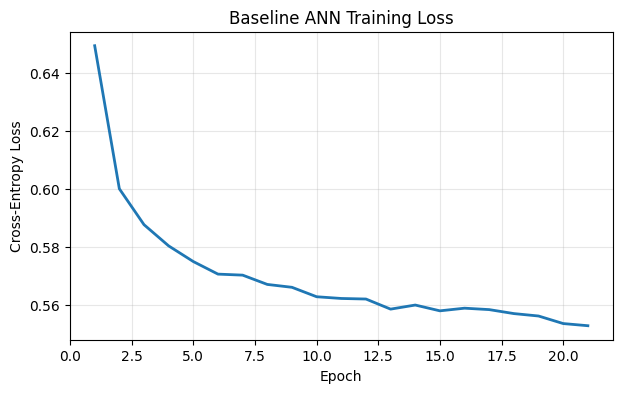

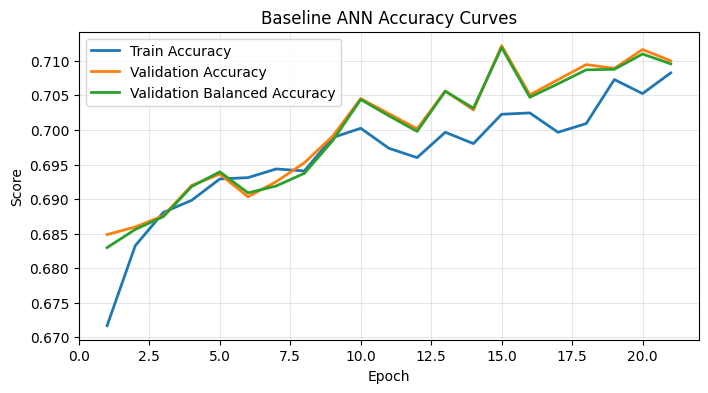


Baseline Validation Results
---------------------------
accuracy: 0.7122
balanced_accuracy: 0.7119
f1_relax: 0.7031
roc_auc: 0.7851
brier_score: 0.1879
accuracy 95% CI: [0.6903, 0.7332]
balanced_accuracy 95% CI: [0.6904, 0.7331]
f1_relax 95% CI: [0.6806, 0.7258]


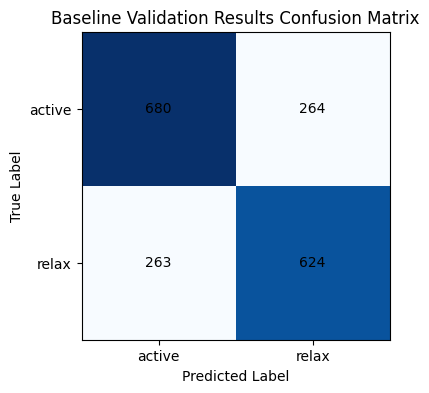


Baseline New Data Test Results
------------------------------
accuracy: 0.6926
balanced_accuracy: 0.6927
f1_relax: 0.6875
roc_auc: 0.7732
brier_score: 0.1929
accuracy 95% CI: [0.6749, 0.7072]
balanced_accuracy 95% CI: [0.6751, 0.7075]
f1_relax 95% CI: [0.6681, 0.7073]


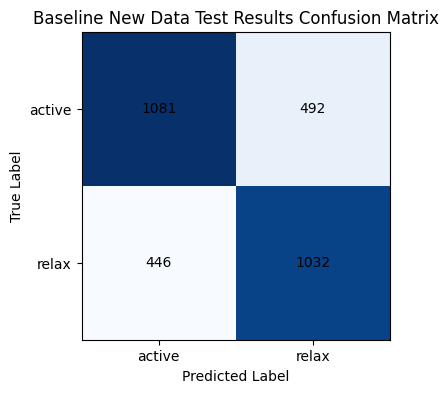

Saved model to spotify_final_baseline_model.pt


In [6]:
baseline_model = BaselineANN(input_dim=len(BASELINE_FEATURE_COLS), hidden_dim=48, num_classes=2)
print(baseline_model)
print("Baseline parameters:", count_parameters(baseline_model))

baseline_history, baseline_best_val_bal_acc = train_torch_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    train_labels=train_df["label"],
    num_epochs=25,
    learning_rate=1e-3,
    weight_decay=0.0,
    patience=6,
    label_smoothing=0.0,
    device=device,
)

plot_curves(baseline_history, title_prefix="Baseline ANN")

baseline_val_results = evaluate_torch_model(baseline_model, val_loader, "Baseline Validation Results", device=device)
baseline_new_data_results = evaluate_torch_model(baseline_model, new_data_loader, "Baseline New Data Test Results", device=device)

torch.save(baseline_model.state_dict(), "spotify_final_baseline_model.pt")
print("Saved model to spotify_final_baseline_model.pt")


SpotifyEmbeddingMLP(
  (embeddings): ModuleList(
    (0): Embedding(12, 6)
    (1): Embedding(2, 2)
    (2): Embedding(6, 3)
  )
  (net): Sequential(
    (0): Linear(in_features=48, out_features=160, bias=True)
    (1): BatchNorm1d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.18, inplace=False)
    (4): Linear(in_features=160, out_features=160, bias=True)
    (5): BatchNorm1d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.18, inplace=False)
    (8): Linear(in_features=160, out_features=96, bias=True)
    (9): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.18, inplace=False)
    (12): Linear(in_features=96, out_features=2, bias=True)
  )
)
Primary neural component parameters: 50176
Epoch 01 | loss=0.6378 | train_acc=0.6845 | val_acc=0.6903 | val

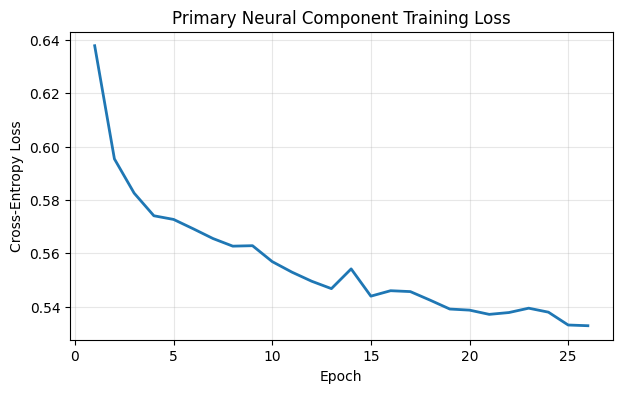

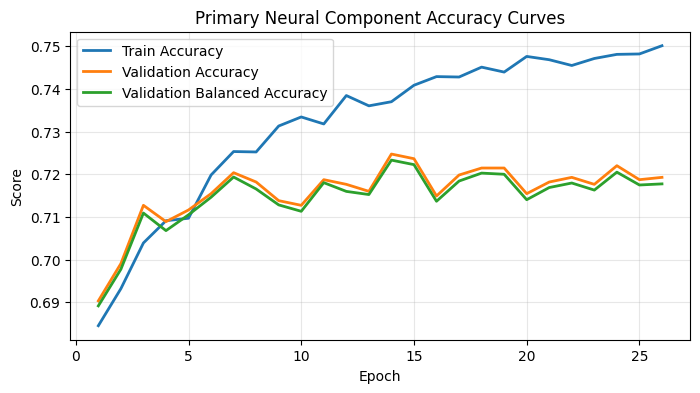


Primary Neural Validation Results
---------------------------------
accuracy: 0.7247
balanced_accuracy: 0.7233
f1_relax: 0.7046
roc_auc: 0.7944
brier_score: 0.1836
accuracy 95% CI: [0.7047, 0.7472]
balanced_accuracy 95% CI: [0.7023, 0.7459]
f1_relax 95% CI: [0.6818, 0.7336]


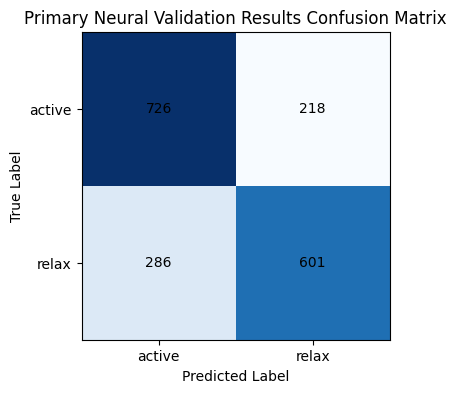


Primary Neural New Data Test Results
------------------------------------
accuracy: 0.7096
balanced_accuracy: 0.7088
f1_relax: 0.6953
roc_auc: 0.7844
brier_score: 0.1883
accuracy 95% CI: [0.6943, 0.7247]
balanced_accuracy 95% CI: [0.6936, 0.7237]
f1_relax 95% CI: [0.6746, 0.7129]


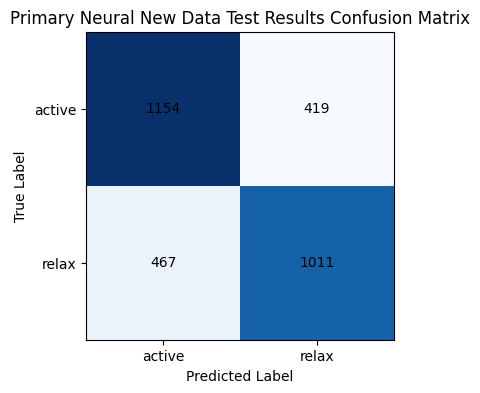


Primary Boosting Validation Results
-----------------------------------
accuracy: 0.7357
balanced_accuracy: 0.7339
f1_relax: 0.7126
roc_auc: 0.8095
brier_score: 0.1768
accuracy 95% CI: [0.7192, 0.7575]
balanced_accuracy 95% CI: [0.7174, 0.7545]
f1_relax 95% CI: [0.6910, 0.7368]


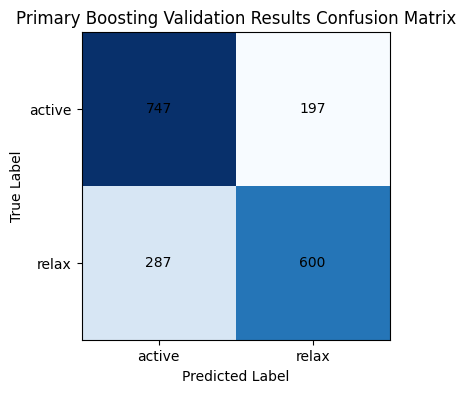


Primary Boosting New Data Test Results
--------------------------------------
accuracy: 0.7234
balanced_accuracy: 0.7218
f1_relax: 0.7011
roc_auc: 0.8048
brier_score: 0.1798
accuracy 95% CI: [0.7091, 0.7381]
balanced_accuracy 95% CI: [0.7070, 0.7355]
f1_relax 95% CI: [0.6829, 0.7197]


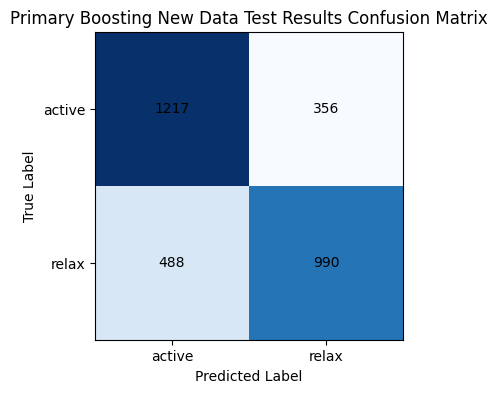


Fitting the hybrid stack on validation predictions only. The held-out new data remains untouched until final evaluation.

Primary Hybrid Validation Results
---------------------------------
accuracy: 0.7389
balanced_accuracy: 0.7367
f1_relax: 0.7120
roc_auc: 0.8127
brier_score: 0.1743
accuracy 95% CI: [0.7205, 0.7596]
balanced_accuracy 95% CI: [0.7187, 0.7563]
f1_relax 95% CI: [0.6897, 0.7368]


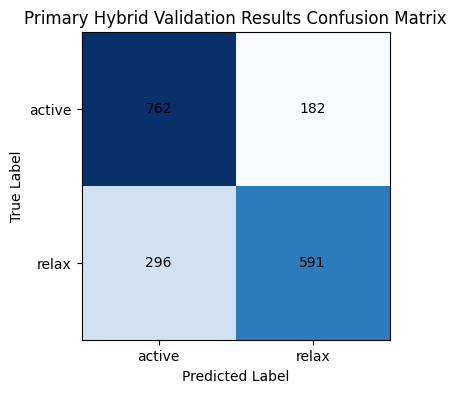


Primary Hybrid New Data Test Results
------------------------------------
accuracy: 0.7266
balanced_accuracy: 0.7246
f1_relax: 0.6998
roc_auc: 0.8051
brier_score: 0.1798
accuracy 95% CI: [0.7129, 0.7415]
balanced_accuracy 95% CI: [0.7094, 0.7384]
f1_relax 95% CI: [0.6796, 0.7183]


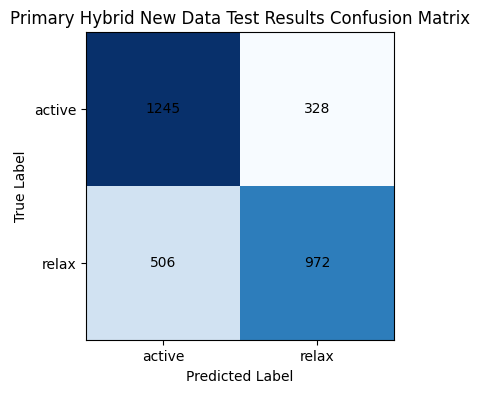

Most confident correct predictions on the new data test set:


,name,true_label_name,pred_label_name,prob_relax,confidence,acousticness,danceability,duration_ms,energy,instrumentalness,...,mode_signed,time_signature_centered,pop_x_energy,pop_x_dance,duration_x_acoustic,loudness_x_valence,acoustic_minus_speech,key,mode,time_signature
2,Standing In The Rain,relax,relax,0.969993,0.969993,0.324000,0.1320,162992,0.952,0.95400,...,-1.0,-1.0,53.312,7.3920,3.888474,-0.000310,0.265100,11.0,0.0,3.0
2998,Waves In The Morning Light,relax,relax,0.969977,0.969977,0.143000,0.0663,168180,0.800,0.63900,...,1.0,-1.0,46.400,3.8454,1.720690,-0.000279,0.046100,1.0,1.0,3.0
698,Thunder Around The Clock,relax,relax,0.969956,0.969956,0.157000,0.1560,140000,0.980,0.99500,...,-1.0,-1.0,58.800,9.3600,1.860357,-0.000288,0.096400,5.0,0.0,3.0
2972,Я люблю дождь,relax,relax,0.969934,0.969934,0.128000,0.1600,134489,0.950,0.99800,...,-1.0,-1.0,59.850,10.0800,1.511583,-0.252163,0.066100,4.0,0.0,3.0
2711,Relaxing Rain Slumber,relax,relax,0.969917,0.969917,0.117000,0.0701,185016,0.879,0.99000,...,1.0,1.0,54.498,4.3462,1.419000,-0.324024,0.060100,5.0,1.0,5.0
368,Graue Wolken,relax,relax,0.969897,0.969897,0.000144,0.0572,208000,0.678,0.92200,...,1.0,-1.0,44.748,3.7752,0.001763,-0.629323,-0.085556,1.0,1.0,3.0
1169,ฝนไทย,relax,relax,0.969893,0.969893,0.139000,0.1770,133003,0.954,0.00772,...,1.0,-3.0,58.194,10.7970,1.639941,-0.267439,0.081700,7.0,1.0,1.0
1512,Exotic Rain,relax,relax,0.969890,0.969890,0.085100,0.2130,201425,0.954,0.95700,...,-1.0,0.0,48.654,10.8630,1.039341,-0.236750,0.029500,0.0,0.0,4.0
2224,Ocean Talking,relax,relax,0.969890,0.969890,0.163000,0.1680,239477,0.802,0.72600,...,-1.0,1.0,41.704,8.7360,2.018953,-0.000293,0.068800,4.0,0.0,5.0
604,Forest Rain,relax,relax,0.969866,0.969866,0.595000,0.1360,208619,0.997,0.93500,...,1.0,1.0,47.856,6.5280,7.287720,-0.000267,0.531200,1.0,1.0,5.0


Most confident errors on the new data test set:


,name,true_label_name,pred_label_name,prob_relax,confidence,acousticness,danceability,duration_ms,energy,instrumentalness,...,mode_signed,time_signature_centered,pop_x_energy,pop_x_dance,duration_x_acoustic,loudness_x_valence,acoustic_minus_speech,key,mode,time_signature
1686,Positive Reaction,active,relax,0.959530,0.959530,0.982,0.0831,190500,0.00171,0.905,...,1.0,0.0,0.10944,5.3184,11.938579,-4.835145,0.9410,2.0,1.0,4.0
432,Peace,active,relax,0.953044,0.953044,0.058,0.1830,218753,0.34500,0.276,...,1.0,0.0,2.07000,1.0980,0.713151,-0.405155,0.0278,2.0,1.0,4.0
1133,For These Reasons,active,relax,0.951552,0.951552,0.912,0.1040,168000,0.00302,0.900,...,1.0,0.0,0.18422,6.3440,10.972933,-1.522151,0.8646,0.0,1.0,4.0
1320,Open Air,active,relax,0.947929,0.947929,0.825,0.1080,163014,0.02730,0.883,...,1.0,-1.0,1.61070,6.3720,9.901318,-1.046109,0.7765,1.0,1.0,3.0
501,Fly Among Clouds,active,relax,0.946967,0.946967,0.921,0.0983,198723,0.03080,0.950,...,-1.0,1.0,1.75560,5.6031,11.235898,-1.134081,0.8813,10.0,0.0,5.0
2220,Quivi,active,relax,0.945367,0.945367,0.990,0.1530,193018,0.02480,0.594,...,-1.0,1.0,1.51280,9.3330,12.048838,-3.377506,0.9442,11.0,0.0,5.0
1121,Halcyon Spirits,active,relax,0.943137,0.943137,0.924,0.1010,154087,0.06060,0.972,...,-1.0,0.0,3.57540,5.9590,11.037438,-1.055770,0.8804,7.0,0.0,4.0
1243,Resolvation,active,relax,0.940494,0.940494,0.968,0.1550,176441,0.00465,0.873,...,1.0,-1.0,0.31155,10.3850,11.694164,-6.147146,0.9158,1.0,1.0,3.0
2708,Serene Lake,active,relax,0.939892,0.939892,0.960,0.0924,156740,0.04280,0.952,...,1.0,0.0,2.52520,5.4516,11.483856,-0.701165,0.9081,1.0,1.0,4.0
1844,Huzurlu,active,relax,0.938585,0.938585,0.960,0.1510,183000,0.02850,0.916,...,-1.0,0.0,1.68150,8.9090,11.632557,-2.659947,0.9220,11.0,0.0,4.0


Permutation importance on the new data test set:


,feature,metric_drop
0,popularity,0.033762
1,intensity_index,0.014869
2,speech_energy,0.012971
3,duration_ms,0.012304
4,valence_minus_acoustic,0.010026
5,dance_valence,0.008235
6,loudness,0.008008
7,acoustic_instr,0.007179
8,speechiness,0.006757
9,pop_x_dance,0.006512


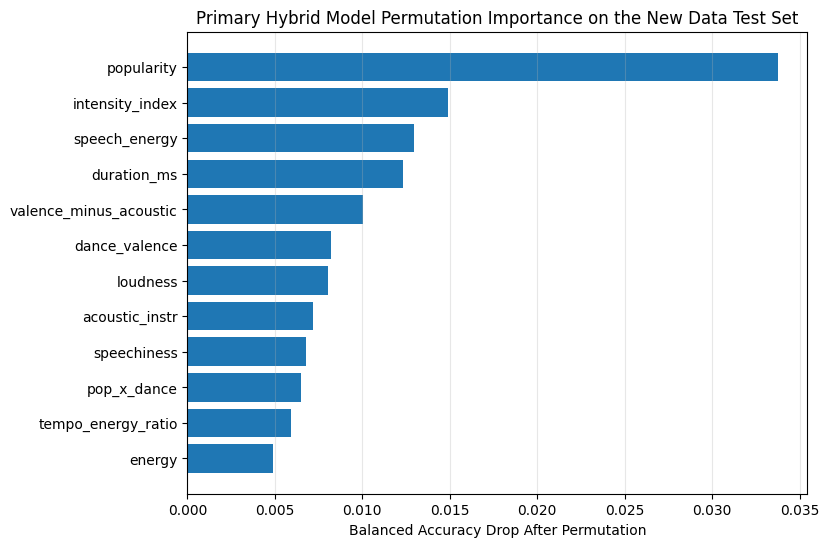

Saved neural component to spotify_final_primary_neural_model.pt
Saved hybrid primary model bundle to spotify_final_primary_model.pt
Final comparison table:


,model,split,num_parameters,best_validation_balanced_accuracy,accuracy,balanced_accuracy,f1_relax,roc_auc,brier_score
0,baseline_ann,validation,1394.0,0.7119,0.7122,0.7119,0.7031,0.7851,0.1879
1,baseline_ann,new_data_test,1394.0,0.7119,0.6926,0.6927,0.6875,0.7732,0.1929
2,primary_neural_mlp,validation,50176.0,0.7233,0.7247,0.7233,0.7046,0.7944,0.1836
3,primary_neural_mlp,new_data_test,50176.0,0.7233,0.7096,0.7088,0.6953,0.7844,0.1883
4,primary_tree_boosting,validation,NaN,0.7339,0.7357,0.7339,0.7126,0.8095,0.1768
5,primary_tree_boosting,new_data_test,NaN,0.7339,0.7234,0.7218,0.7011,0.8048,0.1798
6,primary_hybrid_stack,validation,NaN,0.7367,0.7389,0.7367,0.7120,0.8127,0.1743
7,primary_hybrid_stack,new_data_test,NaN,0.7367,0.7266,0.7246,0.6998,0.8051,0.1798


In [7]:
primary_neural_model = SpotifyEmbeddingMLP(
    continuous_dim=len(PRIMARY_CONTINUOUS_COLS),
    categorical_cardinalities=categorical_cardinalities,
    embedding_dims=(6, 2, 3),
    hidden_dim=160,
    dropout=0.18,
    num_classes=2,
)

print(primary_neural_model)
print("Primary neural component parameters:", count_parameters(primary_neural_model))

primary_neural_history, primary_neural_best_val_bal_acc = train_torch_model(
    model=primary_neural_model,
    train_loader=train_loader,
    val_loader=val_loader,
    train_labels=train_df["label"],
    num_epochs=60,
    learning_rate=3e-4,
    weight_decay=1e-4,
    patience=12,
    label_smoothing=0.02,
    device=device,
)

plot_curves(primary_neural_history, title_prefix="Primary Neural Component")

primary_neural_val_results = evaluate_torch_model(primary_neural_model, val_loader, "Primary Neural Validation Results", device=device)
primary_neural_new_data_results = evaluate_torch_model(primary_neural_model, new_data_loader, "Primary Neural New Data Test Results", device=device)

primary_tree_model = HistGradientBoostingClassifier(
    max_depth=8,
    learning_rate=0.03,
    max_leaf_nodes=127,
    min_samples_leaf=15,
    l2_regularization=0.3,
    random_state=42,
)
primary_tree_model.fit(train_tree_df[TREE_FEATURE_COLS], train_tree_df["label"])

primary_tree_val_probs = primary_tree_model.predict_proba(val_tree_df[TREE_FEATURE_COLS])[:, 1]
primary_tree_new_data_probs = primary_tree_model.predict_proba(new_data_tree_df[TREE_FEATURE_COLS])[:, 1]

primary_tree_val_results = evaluate_probabilities(
    val_tree_df["label"].to_numpy(),
    primary_tree_val_probs,
    "Primary Boosting Validation Results",
)
primary_tree_new_data_results = evaluate_probabilities(
    new_data_tree_df["label"].to_numpy(),
    primary_tree_new_data_probs,
    "Primary Boosting New Data Test Results",
)

print("\nFitting the hybrid stack on validation predictions only. The held-out new data remains untouched until final evaluation.")
stack_train_features = build_stack_features(
    primary_neural_val_results["prob_relax"],
    primary_tree_val_results["prob_relax"],
)
stack_new_data_features = build_stack_features(
    primary_neural_new_data_results["prob_relax"],
    primary_tree_new_data_results["prob_relax"],
)

primary_stack_model = LogisticRegression(max_iter=2000, C=0.5, random_state=42)
primary_stack_model.fit(stack_train_features, val_tree_df["label"].to_numpy())

primary_val_probs = primary_stack_model.predict_proba(stack_train_features)[:, 1]
primary_new_data_probs = primary_stack_model.predict_proba(stack_new_data_features)[:, 1]

primary_val_results = evaluate_probabilities(
    val_tree_df["label"].to_numpy(),
    primary_val_probs,
    "Primary Hybrid Validation Results",
)
primary_new_data_results = evaluate_probabilities(
    new_data_tree_df["label"].to_numpy(),
    primary_new_data_probs,
    "Primary Hybrid New Data Test Results",
)

new_data_predictions_df = build_prediction_table(new_data_tree_df, primary_new_data_results)

print("Most confident correct predictions on the new data test set:")
display(
    new_data_predictions_df[new_data_predictions_df["correct"]]
    .sort_values("confidence", ascending=False)
    .head(10)[[NAME_COL, "true_label_name", "pred_label_name", "prob_relax", "confidence"] + REPORT_FEATURE_COLS]
)

print("Most confident errors on the new data test set:")
display(
    new_data_predictions_df[~new_data_predictions_df["correct"]]
    .sort_values("confidence", ascending=False)
    .head(10)[[NAME_COL, "true_label_name", "pred_label_name", "prob_relax", "confidence"] + REPORT_FEATURE_COLS]
)

importance_df = permutation_importance_from_predictor(
    lambda df: hybrid_predict_proba(df, primary_neural_model, primary_tree_model, primary_stack_model, device=device),
    new_data_tree_df,
    metric_name="balanced_accuracy",
)
print("Permutation importance on the new data test set:")
display(importance_df.head(12))

plt.figure(figsize=(8, 6))
plt.barh(importance_df.head(12).iloc[::-1]["feature"], importance_df.head(12).iloc[::-1]["metric_drop"])
plt.title("Primary Hybrid Model Permutation Importance on the New Data Test Set")
plt.xlabel("Balanced Accuracy Drop After Permutation")
plt.grid(axis="x", alpha=0.3)
plt.show()

torch.save(primary_neural_model.state_dict(), "spotify_final_primary_neural_model.pt")
torch.save(
    {
        "neural_state_dict": primary_neural_model.state_dict(),
        "tree_model": primary_tree_model,
        "stack_model": primary_stack_model,
        "categorical_cardinalities": categorical_cardinalities,
        "primary_continuous_cols": PRIMARY_CONTINUOUS_COLS,
        "categorical_input_cols": CATEGORICAL_INPUT_COLS,
        "tree_feature_cols": TREE_FEATURE_COLS,
        "nn_standardized_feature_cols": NN_STANDARDIZED_FEATURE_COLS,
        "train_means": train_means.to_dict(),
        "train_stds": train_stds.to_dict(),
    },
    "spotify_final_primary_model.pt",
)
print("Saved neural component to spotify_final_primary_neural_model.pt")
print("Saved hybrid primary model bundle to spotify_final_primary_model.pt")

summary_rows = []
for model_name, eval_output, split_name, num_params, best_val in [
    ("baseline_ann", baseline_val_results, "validation", count_parameters(baseline_model), baseline_best_val_bal_acc),
    ("baseline_ann", baseline_new_data_results, "new_data_test", count_parameters(baseline_model), baseline_best_val_bal_acc),
    ("primary_neural_mlp", primary_neural_val_results, "validation", count_parameters(primary_neural_model), primary_neural_best_val_bal_acc),
    ("primary_neural_mlp", primary_neural_new_data_results, "new_data_test", count_parameters(primary_neural_model), primary_neural_best_val_bal_acc),
    ("primary_tree_boosting", primary_tree_val_results, "validation", np.nan, primary_tree_val_results["metrics"]["balanced_accuracy"]),
    ("primary_tree_boosting", primary_tree_new_data_results, "new_data_test", np.nan, primary_tree_val_results["metrics"]["balanced_accuracy"]),
    ("primary_hybrid_stack", primary_val_results, "validation", np.nan, primary_val_results["metrics"]["balanced_accuracy"]),
    ("primary_hybrid_stack", primary_new_data_results, "new_data_test", np.nan, primary_val_results["metrics"]["balanced_accuracy"]),
]:
    metrics = eval_output["metrics"]
    summary_rows.append({
        "model": model_name,
        "split": split_name,
        "num_parameters": num_params,
        "best_validation_balanced_accuracy": best_val,
        "accuracy": metrics["accuracy"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "f1_relax": metrics["f1_relax"],
        "roc_auc": metrics["roc_auc"],
        "brier_score": metrics["brier_score"],
    })

summary_df = pd.DataFrame(summary_rows)
print("Final comparison table:")
display(summary_df.round(4))


### Report Figure Visualizations

In [8]:
from matplotlib.patches import FancyBboxPatch

plt.rcParams.update({
    "figure.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
    "axes.titlesize": 12,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

PALETTE = {
    "ink": "#10233f",
    "muted": "#5b6b82",
    "blue": "#2563eb",
    "sky": "#dbeafe",
    "teal": "#0f766e",
    "mint": "#ccfbf1",
    "amber": "#d97706",
    "sand": "#fef3c7",
    "rose": "#e11d48",
    "blush": "#ffe4e6",
    "violet": "#7c3aed",
    "lavender": "#ede9fe",
    "slate": "#e2e8f0",
}


def rounded_box(ax, x, y, w, h, label, facecolor, edgecolor=None, fontsize=9, weight="bold"):
    rect = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.02,rounding_size=0.025",
        linewidth=1.2,
        edgecolor=edgecolor or PALETTE["ink"],
        facecolor=facecolor,
    )
    ax.add_patch(rect)
    ax.text(
        x + w / 2,
        y + h / 2,
        label,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight=weight,
        color=PALETTE["ink"],
    )


def arrow(ax, x1, y1, x2, y2, text=None, color=None, y_text_offset=0.03):
    arrow_color = color or PALETTE["muted"]
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-|>", lw=1.5, color=arrow_color, shrinkA=2, shrinkB=2),
    )
    if text:
        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2 + y_text_offset,
            text,
            ha="center",
            va="center",
            fontsize=8,
            color=arrow_color,
        )


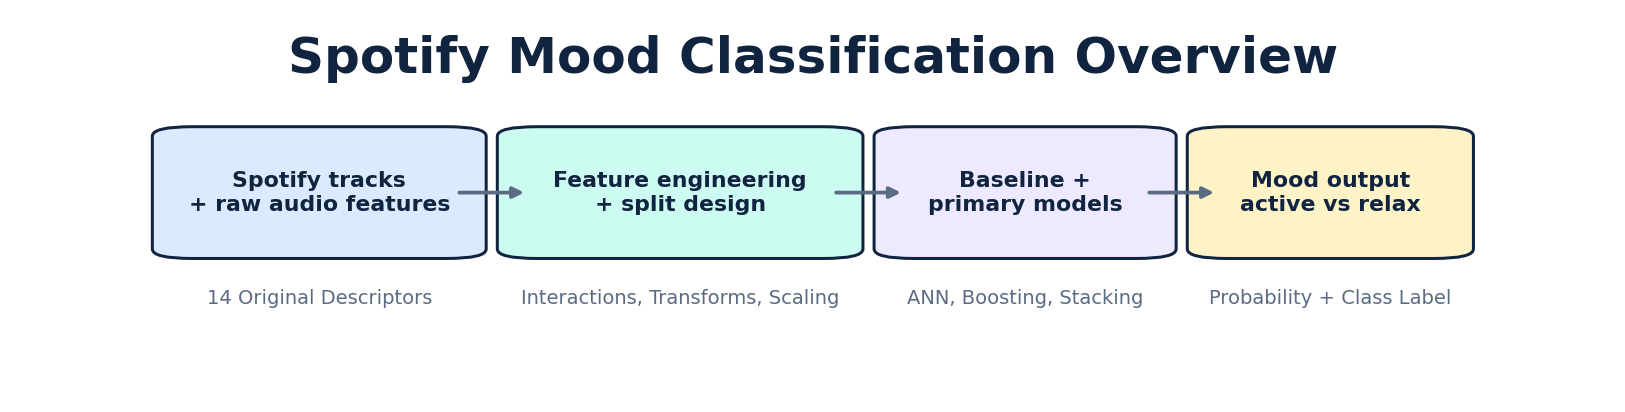

In [89]:
fig, ax = plt.subplots(figsize=(9.2, 2.35))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(
    0.5, 0.89,
    "Spotify Mood Classification Overview",
    ha="center", va="center",
    fontsize=20,
    fontweight="bold",
    color=PALETTE["ink"]
)

gap = 0.047
y = 0.38
h = 0.31

widths = [0.17, 0.19, 0.15, 0.14]
labels = [
    "Spotify tracks\n+ raw audio features",
    "Feature engineering\n+ split design",
    "Baseline +\nprimary models",
    "Mood output\nactive vs relax",
]
colors = [
    PALETTE["sky"],
    PALETTE["mint"],
    PALETTE["lavender"],
    PALETTE["sand"],
]

total_width = sum(widths) + gap * (len(widths) - 1)
start_x = (1 - total_width) / 2

x_positions = [start_x]
for w in widths[:-1]:
    x_positions.append(x_positions[-1] + w + gap)

steps = [
    (x, y, w, h, label, color)
    for x, w, label, color in zip(x_positions, widths, labels, colors)
]

for x, y, w, h, label, color in steps:
    rounded_box(ax, x, y, w, h, label, color, fontsize=8.8)

for (x, y, w, h, _, _), (nx, ny, nw, nh, _, _) in zip(steps[:-1], steps[1:]):
    arrow(ax, x + w, y + h / 2, nx, ny + nh / 2)

ax.text(x_positions[0] + widths[0] / 2, 0.24, "14 Original Descriptors", ha="center", color=PALETTE["muted"], fontsize=7.8)
ax.text(x_positions[1] + widths[1] / 2, 0.24, "Interactions, Transforms, Scaling", ha="center", color=PALETTE["muted"], fontsize=7.8)
ax.text(x_positions[2] + widths[2] / 2, 0.24, "ANN, Boosting, Stacking", ha="center", color=PALETTE["muted"], fontsize=7.8)
ax.text(x_positions[3] + widths[3] / 2, 0.24, "Probability + Class Label", ha="center", color=PALETTE["muted"], fontsize=7.8)

plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.06)
plt.show()

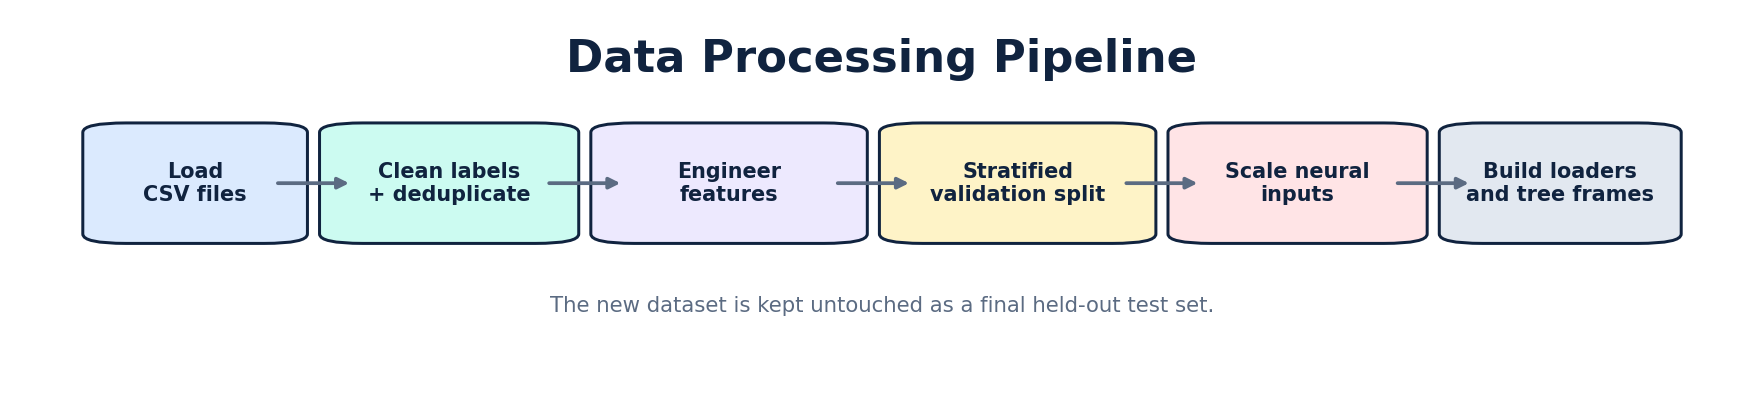

In [90]:
fig, ax = plt.subplots(figsize=(10.0, 2.35))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(
    0.5, 0.89,
    "Data Processing Pipeline",
    ha="center", va="center",
    fontsize=18,
    fontweight="bold",
    color=PALETTE["ink"]
)

gap = 0.047
y = 0.42
h = 0.28

widths = [0.09, 0.11, 0.12, 0.12, 0.11, 0.10]
labels = [
    "Load\nCSV files",
    "Clean labels\n+ deduplicate",
    "Engineer\nfeatures",
    "Stratified\nvalidation split",
    "Scale neural\ninputs",
    "Build loaders\nand tree frames",
]
colors = [
    PALETTE["sky"],
    PALETTE["mint"],
    PALETTE["lavender"],
    PALETTE["sand"],
    PALETTE["blush"],
    PALETTE["slate"],
]

total_width = sum(widths) + gap * (len(widths) - 1)
start_x = (1 - total_width) / 2

x_positions = [start_x]
for w in widths[:-1]:
    x_positions.append(x_positions[-1] + w + gap)

steps = [
    (x, y, w, h, label, color)
    for x, w, label, color in zip(x_positions, widths, labels, colors)
]

for x, y, w, h, label, color in steps:
    rounded_box(ax, x, y, w, h, label, color, fontsize=8.3)

for (x, y, w, h, _, _), (nx, ny, nw, nh, _, _) in zip(steps[:-1], steps[1:]):
    arrow(ax, x + w, y + h / 2, nx, ny + nh / 2, y_text_offset=0.0)

ax.text(
    0.5, 0.22,
    "The new dataset is kept untouched as a final held-out test set.",
    ha="center",
    color=PALETTE["muted"],
    fontsize=8.5
)

plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.06)
plt.show()

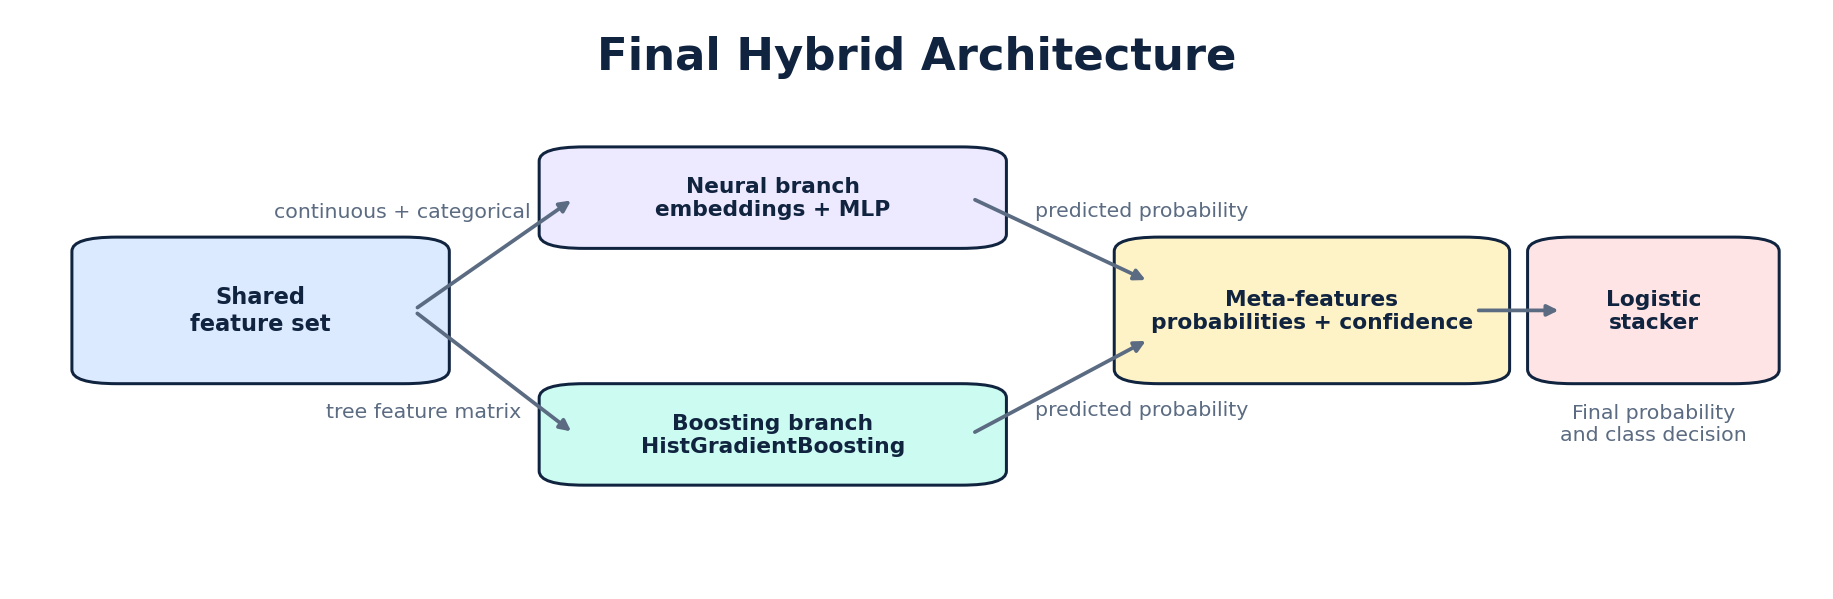

In [74]:
fig, ax = plt.subplots(figsize=(10.4, 3.6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(
    0.5, 0.93,
    "Final Hybrid Architecture",
    ha="center", va="center",
    fontsize=18,
    fontweight="bold",
    color=PALETTE["ink"]
)

# Boxes
rounded_box(ax, 0.05, 0.37, 0.17, 0.22, "Shared\nfeature set", PALETTE["sky"], fontsize=9)
rounded_box(ax, 0.31, 0.61, 0.22, 0.14, "Neural branch\nembeddings + MLP", PALETTE["lavender"], fontsize=8.7)
rounded_box(ax, 0.31, 0.19, 0.22, 0.14, "Boosting branch\nHistGradientBoosting", PALETTE["mint"], fontsize=8.7)
rounded_box(ax, 0.63, 0.37, 0.18, 0.22, "Meta-features\nprobabilities + confidence", PALETTE["sand"], fontsize=8.7)
rounded_box(ax, 0.86, 0.37, 0.10, 0.22, "Logistic\nstacker", PALETTE["blush"], fontsize=8.7)

# Arrows
arrow(ax, 0.22, 0.48, 0.31, 0.68, y_text_offset=0.0)
arrow(ax, 0.22, 0.48, 0.31, 0.26, y_text_offset=0.0)
arrow(ax, 0.53, 0.68, 0.63, 0.53, y_text_offset=0.0)
arrow(ax, 0.53, 0.26, 0.63, 0.43, y_text_offset=0.0)
arrow(ax, 0.81, 0.48, 0.86, 0.48, y_text_offset=0.0)

# Labels moved beside arrows instead of on them
ax.text(
    0.285, 0.655,
    "continuous + categorical",
    ha="right", va="center",
    fontsize=8.2,
    color=PALETTE["muted"]
)
ax.text(
    0.28, 0.3,
    "tree feature matrix",
    ha="right", va="center",
    fontsize=8.2,
    color=PALETTE["muted"]
)

ax.text(
    0.625, 0.64,
    "predicted probability",
    ha="center", va="bottom",
    fontsize=8.2,
    color=PALETTE["muted"]
)
ax.text(
    0.625, 0.32,
    "predicted probability",
    ha="center", va="top",
    fontsize=8.2,
    color=PALETTE["muted"]
)

ax.text(
    0.91, 0.25,
    "Final probability\nand class decision",
    ha="center",
    fontsize=8.2,
    color=PALETTE["muted"]
)

plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.08)
plt.show()

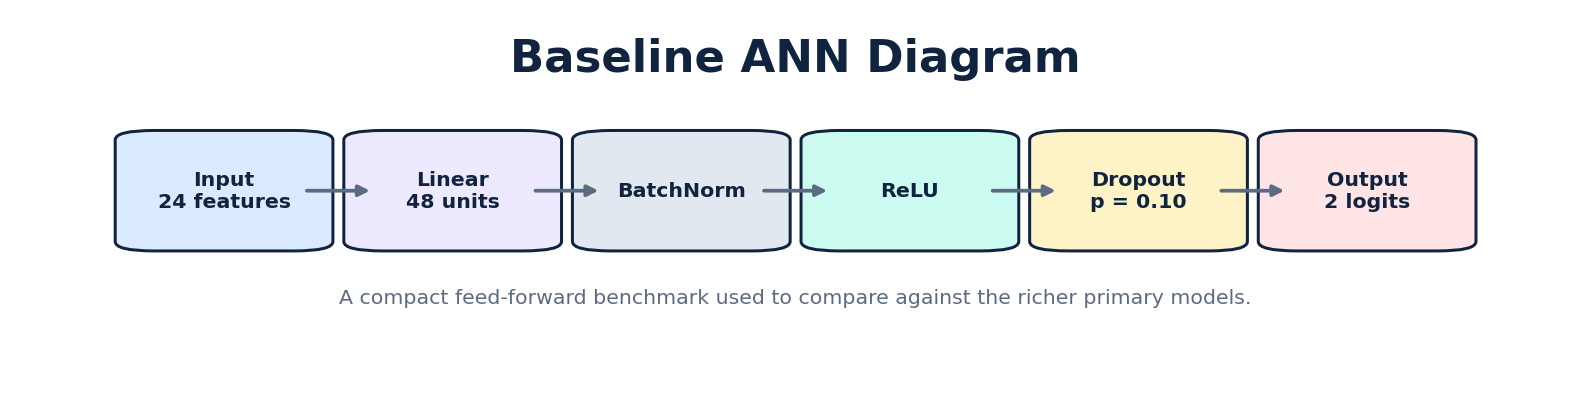

In [87]:
fig, ax = plt.subplots(figsize=(9.0, 2.35))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(
    0.5, 0.89,
    "Baseline ANN Diagram",
    ha="center", va="center",
    fontsize=18,
    fontweight="bold",
    color=PALETTE["ink"]
)

baseline_labels = [
    f"Input\n{len(BASELINE_FEATURE_COLS)} features",
    "Linear\n48 units",
    "BatchNorm",
    "ReLU",
    "Dropout\np = 0.10",
    "Output\n2 logits",
]

colors = [
    PALETTE["sky"],
    PALETTE["lavender"],
    PALETTE["slate"],
    PALETTE["mint"],
    PALETTE["sand"],
    PALETTE["blush"],
]

gap = 0.047
y = 0.40
w = 0.10
h = 0.28

total_width = 6 * w + 5 * gap
start_x = (1 - total_width) / 2
x_positions = [start_x + i * (w + gap) for i in range(6)]

for x, label, color in zip(x_positions, baseline_labels, colors):
    rounded_box(ax, x, y, w, h, label, color, fontsize=8.2)

for left, right in zip(x_positions[:-1], x_positions[1:]):
    arrow(ax, left + w, y + h / 2, right, y + h / 2, y_text_offset=0.0)

ax.text(
    0.5,
    0.24,
    "A compact feed-forward benchmark used to compare against the richer primary models.",
    ha="center",
    color=PALETTE["muted"],
    fontsize=8.2,
)

plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.06)
plt.show()

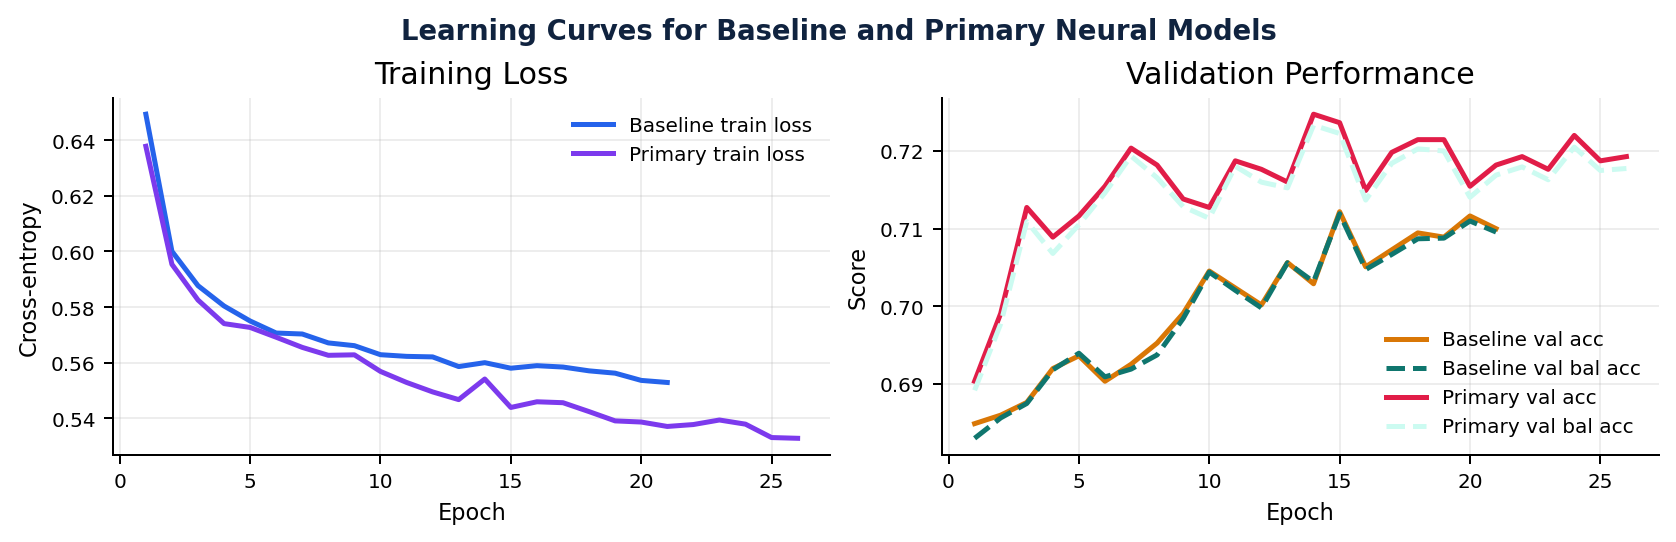

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 2.9), constrained_layout=True)
fig.suptitle(
    "Learning Curves for Baseline and Primary Neural Models",
    color=PALETTE["ink"],
    fontweight="bold",
    fontsize=11
)

baseline_epochs = np.arange(1, len(baseline_history["train_loss"]) + 1)
primary_epochs = np.arange(1, len(primary_neural_history["train_loss"]) + 1)

# Left panel: loss
axes[0].plot(
    baseline_epochs,
    baseline_history["train_loss"],
    label="Baseline train loss",
    color=PALETTE["blue"],
    lw=2
)
axes[0].plot(
    primary_epochs,
    primary_neural_history["train_loss"],
    label="Primary train loss",
    color=PALETTE["violet"],
    lw=2
)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy")
axes[0].grid(alpha=0.22)
axes[0].legend(frameon=False, fontsize=8)

# Right panel: validation accuracy
axes[1].plot(
    baseline_epochs,
    baseline_history["val_accuracy"],
    label="Baseline val acc",
    color=PALETTE["amber"],
    lw=2
)
axes[1].plot(
    baseline_epochs,
    baseline_history["val_balanced_accuracy"],
    label="Baseline val bal acc",
    color=PALETTE["teal"],
    lw=2,
    linestyle="--"
)
axes[1].plot(
    primary_epochs,
    primary_neural_history["val_accuracy"],
    label="Primary val acc",
    color=PALETTE["rose"],
    lw=2
)
axes[1].plot(
    primary_epochs,
    primary_neural_history["val_balanced_accuracy"],
    label="Primary val bal acc",
    color=PALETTE["mint"],
    lw=2,
    linestyle="--"
)
axes[1].set_title("Validation Performance")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].grid(alpha=0.22)
axes[1].legend(frameon=False, fontsize=8, loc="lower right")

plt.show()